## 1 Overview

## 2 Importing Libraries

In [1]:
# Importing required libraries
from pathlib import Path

import random
import pandas as pd
import matplotlib.pyplot as plt

from datasets import load_dataset

c:\Users\Subathra\OneDrive\Desktop\cm3020_Final_Year_project\CM3020_Final_Year_Project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 3 Loading Dataset

In [2]:
# reproducible evaluation
SEED = 42

# same sample sizes used in translation model evaluation
VALIDATION_SIZE = 100
TEST_SIZE = 100

# OPUS-100 dataset
DATASET_ID = "Helsinki-NLP/opus-100"

# language pairs used in the project
dataset_configs = {
    "Malay": {
        "config": "en-ms",
        "target": "ms"
    },
    "Chinese": {
        "config": "en-zh",
        "target": "zh"
    },
    "Tamil": {
        "config": "en-ta",
        "target": "ta"
    }
}

In [3]:
# dictionaries for validation and testing datasets
validation_datasets = {}
testing_datasets = {}

for language, details in dataset_configs.items():

    print(f"Loading {language}...")

    validation_datasets[language] = (
        load_dataset(
            DATASET_ID,
            details["config"],
            split="validation"
        )
    )

    testing_datasets[language] = (
        load_dataset(
            DATASET_ID,
            details["config"],
            split="test"
        )
    )

Loading Malay...
Loading Chinese...
Loading Tamil...


In [4]:
# number of records in each original split
split_results = []

for language in dataset_configs:

    split_results.append({
        "Language": language,
        "Validation Records":
            len(
                validation_datasets[
                    language
                ]
            ),
        "Testing Records":
            len(
                testing_datasets[
                    language
                ]
            )
    })

df_splits = pd.DataFrame(
    split_results
)

df_splits

,Language,Validation Records,Testing Records
0,Malay,2000,2000
1,Chinese,2000,2000
2,Tamil,2000,2000


## 4 Understanding Translation Records

In [5]:
# dataset columns
for language in dataset_configs:

    print(
        language,
        validation_datasets[
            language
        ].column_names
    )

Malay ['translation']
Chinese ['translation']
Tamil ['translation']


In [6]:
# first five English-reference translation pairs
for language, details in dataset_configs.items():

    target = details["target"]
    dataset = validation_datasets[
        language
    ]

    samples = []

    for index in range(
        min(5, len(dataset))
    ):

        translation = (
            dataset[index][
                "translation"
            ]
        )

        samples.append({
            "English":
                translation["en"],
            language:
                translation[target]
        })

    print(
        f"\n{language}"
    )

    display(
        pd.DataFrame(samples)
    )


Malay


,English,Malay
0,Is this why you gave up the staff surgeon posi...,Ini sebabnya kau menolak kedudukan di Hospital...
1,Ray's working.,Ray sedang bekerja.
2,Don't you know he has a phobia of fire? ! Phob...,Kamu tak tahu dia takutkan api?
3,Almost time for dinner.,Hampir masa untuk makan malam.
4,"God, why didn't you charge it?",Kenapa awak tak cas ia?



Chinese


,English,Chinese
0,"ILOAT, however, appeared to have the edge over...",然而，劳工组织行政法庭相对于联合国行政法庭似乎有些优势。
1,Tell you what. I can give you a ride to Belle'...,这样吧，我载你们到5英里外的贝拉餐厅
2,A/AC.154/363 Letter dated 20 September 2005 fr...,A/AC.154/363 2005年9月20日美利坚合众国常驻联合国代表给委员会主席的信 [...
3,"He's in jail. Maximum security, for Christ's s...",- 他人在戒备森严的牢里
4,Throughout the nineteenth century and in the f...,在整个十九世纪和二十世纪上半叶，正如我们先前听到的那样，有6 000多万欧洲人移民海外，主要...



Tamil


,English,Tamil
0,default:LTR,default:LTR
1,Minimum height set,குறைந்தபட்ச உயரத்தை அமைக்கவும்
2,You follow your religion and I follow mine.,உங்களுக்கு உங்களுடைய மார்க்கம்; எனக்கு என்னுடை...
3,Mixer cannot be found,கலப்பான் இல்லை
4,Tools,கருவிகள்


## 5 Split Distribution

In [7]:
# validation and testing distribution
distribution = pd.DataFrame({
    "Validation": {
        language:
            len(
                validation_datasets[
                    language
                ]
            )
        for language
        in dataset_configs
    },
    "Testing": {
        language:
            len(
                testing_datasets[
                    language
                ]
            )
        for language
        in dataset_configs
    }
})

distribution

,Validation,Testing
Malay,2000,2000
Chinese,2000,2000
Tamil,2000,2000


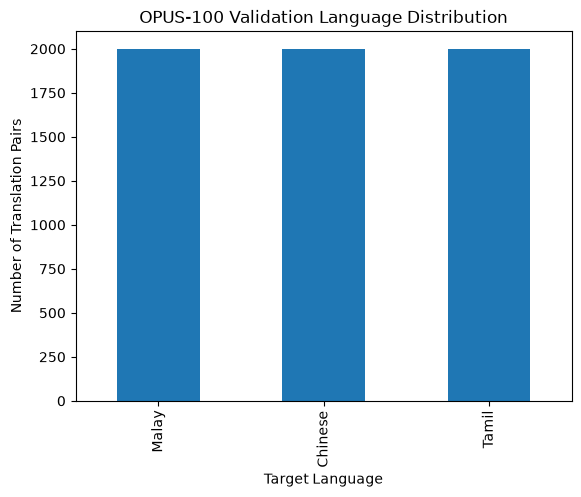

In [8]:
# validation distribution
distribution[
    "Validation"
].plot(
    kind="bar"
)

plt.title(
    "OPUS-100 Validation Language Distribution"
)
plt.xlabel("Target Language")
plt.ylabel("Number of Translation Pairs")
plt.show()

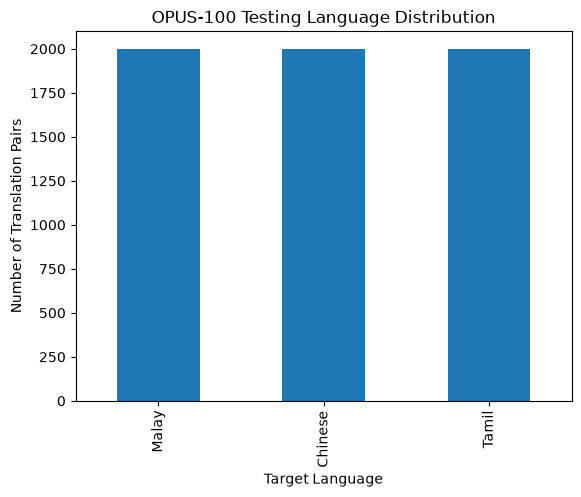

In [9]:
# testing distribution
distribution[
    "Testing"
].plot(
    kind="bar"
)

plt.title(
    "OPUS-100 Testing Language Distribution"
)
plt.xlabel("Target Language")
plt.ylabel("Number of Translation Pairs")
plt.show()

## 6 Checking Translation Text

In [10]:
# translation-data checks
checks = []

for language, details in dataset_configs.items():

    target = details["target"]

    for split_name, dataset in [
        (
            "Validation",
            validation_datasets[
                language
            ]
        ),
        (
            "Testing",
            testing_datasets[
                language
            ]
        )
    ]:

        sources = []
        references = []

        for record in dataset:

            translation = record[
                "translation"
            ]

            sources.append(
                translation.get(
                    "en"
                )
            )

            references.append(
                translation.get(
                    target
                )
            )

        source_series = pd.Series(
            sources,
            dtype="object"
        )

        reference_series = pd.Series(
            references,
            dtype="object"
        )

        pair_dataframe = pd.DataFrame({
            "source": source_series,
            "reference":
                reference_series
        })

        checks.append({
            "Language": language,
            "Split": split_name,

            "Missing English":
                source_series
                .isnull()
                .sum(),

            "Empty English":
                source_series
                .fillna("")
                .astype(str)
                .str.strip()
                .eq("")
                .sum(),

            "Missing Reference":
                reference_series
                .isnull()
                .sum(),

            "Empty Reference":
                reference_series
                .fillna("")
                .astype(str)
                .str.strip()
                .eq("")
                .sum(),

            "Duplicated English":
                source_series
                .duplicated()
                .sum(),

            "Duplicated Pairs":
                pair_dataframe
                .duplicated()
                .sum()
        })

In [11]:
# dataframe for the checks
df_checks = pd.DataFrame(
    checks
)

df_checks

,Language,Split,Missing English,Empty English,Missing Reference,Empty Reference,Duplicated English,Duplicated Pairs
0,Malay,Validation,0,0,0,0,31,17
1,Malay,Testing,0,0,0,0,25,15
2,Chinese,Validation,0,0,0,0,1,1
3,Chinese,Testing,0,0,0,0,1,0
4,Tamil,Validation,0,0,0,0,502,331
5,Tamil,Testing,0,0,0,0,497,310


## 7 Checking Validation/Test

In [12]:
# check exact source and translation-pair overlap
overlap_results = []

for language, details in dataset_configs.items():

    target = details["target"]

    validation_pairs = {
        (
            str(
                record["translation"]["en"]
            ).strip(),
            str(
                record[
                    "translation"
                ][target]
            ).strip()
        )
        for record
        in validation_datasets[
            language
        ]
    }

    testing_pairs = {
        (
            str(
                record["translation"]["en"]
            ).strip(),
            str(
                record[
                    "translation"
                ][target]
            ).strip()
        )
        for record
        in testing_datasets[
            language
        ]
    }

    validation_sources = {
        pair[0]
        for pair in validation_pairs
    }

    testing_sources = {
        pair[0]
        for pair in testing_pairs
    }

    overlap_results.append({
        "Language": language,

        "Exact Pair Overlap":
            len(
                validation_pairs
                & testing_pairs
            ),

        "English Source Overlap":
            len(
                validation_sources
                & testing_sources
            )
    })

In [13]:
df_overlap = pd.DataFrame(
    overlap_results
)

df_overlap

,Language,Exact Pair Overlap,English Source Overlap
0,Malay,17,27
1,Chinese,0,1
2,Tamil,307,349


## 8 Checking Text Lengths

In [14]:
# text-length properties
length_records = []

for language, details in dataset_configs.items():

    target = details["target"]

    for split_name, dataset in [
        (
            "Validation",
            validation_datasets[
                language
            ]
        ),
        (
            "Testing",
            testing_datasets[
                language
            ]
        )
    ]:

        for record in dataset:

            translation = (
                record[
                    "translation"
                ]
            )

            source = str(
                translation["en"]
            )

            reference = str(
                translation[target]
            )

            length_records.append({
                "Language": language,
                "Split": split_name,

                "Source Characters":
                    len(source),

                "Reference Characters":
                    len(reference),

                "Source Words":
                    len(
                        source.split()
                    )
            })

In [15]:
# dataframe
df_lengths = pd.DataFrame(
    length_records
)

df_lengths.head()

,Language,Split,Source Characters,Reference Characters,Source Words
0,Malay,Validation,71,66,13
1,Malay,Validation,14,19,2
2,Malay,Validation,57,31,13
3,Malay,Validation,23,30,4
4,Malay,Validation,30,23,6


In [16]:
# English source character lengths
df_lengths[
    "Source Characters"
].describe().to_frame()

,Source Characters
count,12000.000000
mean,71.126750
std,98.484443
min,1.000000
25%,19.000000
50%,36.000000
75%,79.000000
max,2236.000000


In [17]:
# target reference character lengths
df_lengths[
    "Reference Characters"
].describe().to_frame()

,Reference Characters
count,12000.000000
mean,43.951417
std,59.561257
min,1.000000
25%,16.000000
50%,30.000000
75%,51.000000
max,2058.000000


In [18]:
# lengths for each language
df_lengths.groupby(
    "Language"
)[
    [
        "Source Characters",
        "Reference Characters"
    ]
].describe()

Source Characters                                                  \
                     count       mean         std  min   25%    50%    75%   
Language                                                                     
Chinese             4000.0  136.81300  131.943423  4.0  44.0  104.0  192.0   
Malay               4000.0   39.28650   31.246736  3.0  21.0   32.0   48.0   
Tamil               4000.0   37.28075   65.125466  1.0   9.0   18.0   37.0   

                 Reference Characters                                        \
             max                count      mean        std  min   25%   50%   
Language                                                                      
Chinese   2236.0               4000.0  40.62200  39.868860  2.0  14.0  31.0   
Malay      744.0               4000.0  42.64075  39.297071  3.0  22.0  33.0   
Tamil     1586.0               4000.0  48.59150  86.465465  1.0  12.0  24.0   

                        
           75%     max  
Language                
Chinese   55.0   858.0  
Malay     51.0   782.0  
Tamil     44.0  2058.0

## 9 Evaluation Splits

In [19]:
# reproducible validation and testing indices
validation_indices = {}
testing_indices = {}

for language in dataset_configs:

    validation_indices[
        language
    ] = random.Random(
        SEED
    ).sample(
        range(
            len(
                validation_datasets[
                    language
                ]
            )
        ),
        VALIDATION_SIZE
    )

    testing_indices[
        language
    ] = random.Random(
        SEED + 1
    ).sample(
        range(
            len(
                testing_datasets[
                    language
                ]
            )
        ),
        TEST_SIZE
    )

In [20]:
# prepare selected evaluation data
validation_data = {}
testing_data = {}

for language, details in dataset_configs.items():

    target = details["target"]

    validation_data[
        language
    ] = pd.DataFrame({
        "source": [
            validation_datasets[
                language
            ][index][
                "translation"
            ]["en"]
            for index
            in validation_indices[
                language
            ]
        ],

        "reference": [
            validation_datasets[
                language
            ][index][
                "translation"
            ][target]
            for index
            in validation_indices[
                language
            ]
        ]
    })

    testing_data[
        language
    ] = pd.DataFrame({
        "source": [
            testing_datasets[
                language
            ][index][
                "translation"
            ]["en"]
            for index
            in testing_indices[
                language
            ]
        ],

        "reference": [
            testing_datasets[
                language
            ][index][
                "translation"
            ][target]
            for index
            in testing_indices[
                language
            ]
        ]
    })

In [21]:
# evaluation counts
evaluation_counts = []

for language in dataset_configs:

    evaluation_counts.append({
        "Language": language,

        "Validation Records":
            len(
                validation_data[
                    language
                ]
            ),

        "Testing Records":
            len(
                testing_data[
                    language
                ]
            )
    })

df_evaluation = pd.DataFrame(
    evaluation_counts
)

df_evaluation

,Language,Validation Records,Testing Records
0,Malay,100,100
1,Chinese,100,100
2,Tamil,100,100


## 10 Selected Evaluation Data

In [22]:
# check selected evaluation records
selected_checks = []

for language in dataset_configs:

    for split_name, dataset in [
        (
            "Validation",
            validation_data[
                language
            ]
        ),
        (
            "Testing",
            testing_data[
                language
            ]
        )
    ]:

        selected_checks.append({
            "Language": language,
            "Split": split_name,

            "Missing Source":
                dataset[
                    "source"
                ].isnull().sum(),

            "Empty Source":
                dataset[
                    "source"
                ]
                .fillna("")
                .str.strip()
                .eq("")
                .sum(),

            "Missing Reference":
                dataset[
                    "reference"
                ].isnull().sum(),

            "Empty Reference":
                dataset[
                    "reference"
                ]
                .fillna("")
                .str.strip()
                .eq("")
                .sum(),

            "Duplicated Pairs":
                dataset
                .duplicated()
                .sum()
        })

In [23]:
pd.DataFrame(
    selected_checks
)

,Language,Split,Missing Source,Empty Source,Missing Reference,Empty Reference,Duplicated Pairs
0,Malay,Validation,0,0,0,0,0
1,Malay,Testing,0,0,0,0,1
2,Chinese,Validation,0,0,0,0,0
3,Chinese,Testing,0,0,0,0,0
4,Tamil,Validation,0,0,0,0,2
5,Tamil,Testing,0,0,0,0,0


In [24]:
# check whether selected validation/test samples overlap
selected_overlap = []

for language in dataset_configs:

    validation_pairs = set(
        map(
            tuple,
            validation_data[
                language
            ][
                [
                    "source",
                    "reference"
                ]
            ].to_numpy()
        )
    )

    testing_pairs = set(
        map(
            tuple,
            testing_data[
                language
            ][
                [
                    "source",
                    "reference"
                ]
            ].to_numpy()
        )
    )

    selected_overlap.append({
        "Language": language,
        "Selected Pair Overlap":
            len(
                validation_pairs
                & testing_pairs
            )
    })

pd.DataFrame(
    selected_overlap
)

,Language,Selected Pair Overlap
0,Malay,0
1,Chinese,0
2,Tamil,2


## 11 Saving Evaluation Data

In [25]:
# processed data folder
processed_folder = Path(
    "../../data/processed/opus100_translation"
)

validation_folder = (
    processed_folder
    / "validation"
)

testing_folder = (
    processed_folder
    / "testing"
)

validation_folder.mkdir(
    parents=True,
    exist_ok=True
)

testing_folder.mkdir(
    parents=True,
    exist_ok=True
)

In [26]:
# save each target language separately
for language in dataset_configs:

    filename = (
        language.lower()
        + ".csv"
    )

    validation_data[
        language
    ].to_csv(
        validation_folder
        / filename,
        index=False
    )

    testing_data[
        language
    ].to_csv(
        testing_folder
        / filename,
        index=False
    )

In [27]:
# confirm files were saved
for language in dataset_configs:

    filename = (
        language.lower()
        + ".csv"
    )

    print(
        language,
        "validation:",
        (
            validation_folder
            / filename
        ).exists(),
        "| testing:",
        (
            testing_folder
            / filename
        ).exists()
    )

Malay validation: True | testing: True
Chinese validation: True | testing: True
Tamil validation: True | testing: True


## 12 Conclusion